<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/algoritma_Q-Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
%pip install gymnasium

In [20]:
import gymnasium as gym
import numpy as np
import random
import time
import sys
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import clear_output

In [21]:
custom_map = [
"SHFH",
"FFFH",
"FHFF",
"HFFG"
]

env = gym.make(
'FrozenLake-v1',
desc = custom_map,
is_slippery = False,
render_mode = "ansi"
)

In [22]:
action_size = env.action_space.n
state_size = env.observation_space.n
q_table = np.zeros((state_size, action_size))

print("Action Size = ", action_size)
print("State Size = ", state_size)
print("\nQ-Table awal = \n")
print(q_table)

Action Size =  4
State Size =  16

Q-Table awal = 

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [23]:
num_episodes = 10000
alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.9995
epsilon_min = 0.01

In [24]:
successful_episode_routes = []
failed_episode_routes = []

for episode in range(num_episodes):

    state, _ = env.reset()
    done = False

    route = [state]

    while not done:

        if episode % 100 == 0:

            clear_output(wait=True)

            print(f"Episode {episode+1} - Training in progress...")

            rendered_output = "".join(env.render())
            sys.stdout.write(rendered_output + "\n")
            sys.stdout.flush()

        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()

        else:
            action = np.argmax(q_table[state, :])

        new_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated

        route.append(new_state)

        q_table[state, action] += alpha * (
            reward + gamma * np.max(q_table[new_state, :])
            - q_table[state, action]
        )

        if done:

            if reward == 1:

                successful_episode_routes.append(
                    (episode + 1, route)
                )

            else:

                failed_episode_routes.append(
                    (episode + 1, route)
                )

            if episode % 100 == 0:

                clear_output(wait=True)

                print(f"Episode {episode+1} - Training in progress...")

                rendered_output = "".join(env.render())
                sys.stdout.write(rendered_output + "\n")
                sys.stdout.flush()

            break

        state = new_state

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("\nTraining Completed!")

Episode 9901 - Training in progress...
  (Down)
SHFH
FFFH
FHFF
HFFG


Training Completed!


In [25]:
success_rate = (len(successful_episode_routes) /
num_episodes) * 100

print(f"Jumlah Episode Berhasil ={len(successful_episode_routes)}")
print(f"Jumlah Episode Gagal ={len(failed_episode_routes)}")
print(f"Persentase Keberhasilan = {success_rate:.2f}%")

Jumlah Episode Berhasil =7311
Jumlah Episode Gagal =2689
Persentase Keberhasilan = 73.11%


In [26]:
def render_route_as_grid(route, is_success, grid_size=4):
    grid = [["." for _ in range(grid_size)] for _ in range(grid_size)]

    for i, state in enumerate(route):
        row, col = divmod(state, grid_size)

        if i == 0:
            grid[row][col] = "S"

        elif i == len(route) - 1:
            grid[row][col] = "G" if is_success else "H"

        else:
            grid[row][col] = "*"

    return "\n".join(" ".join(row) for row in grid)

In [27]:
def save_routes_to_file(filename, episode_routes, is_success):
    with open(filename, "w") as f:

        status = "Berhasil" if is_success else "Gagal"

        f.write(f"Daftar Episode {status} & Rutenya (Grid dan List):\n")

        for ep, route in episode_routes:

            f.write(f"\nEpisode {ep}:\n")

            f.write("Grid:\n")
            f.write(render_route_as_grid(route, is_success))

            f.write("\nList Rute: " + str(route) + "\n")
            f.write("\n")


save_routes_to_file(
    "rute_berhasil.txt",
    successful_episode_routes,
    is_success=True
)

save_routes_to_file(
    "rute_gagal.txt",
    failed_episode_routes,
    is_success=False
)

In [28]:
print("Q-Table = \n")
print(q_table)

Q-Table = 

[[0.531441   0.59049    0.         0.531441  ]
 [0.         0.         0.         0.        ]
 [0.         0.729      0.         0.6154541 ]
 [0.         0.         0.         0.        ]
 [0.59049    0.531441   0.6561     0.531441  ]
 [0.59049    0.         0.729      0.        ]
 [0.6561     0.81       0.         0.6561    ]
 [0.         0.         0.         0.        ]
 [0.52761525 0.         0.         0.59049   ]
 [0.         0.         0.         0.        ]
 [0.         0.9        0.9        0.729     ]
 [0.81       1.         0.9        0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.05764537 0.68980829 0.        ]
 [0.40030656 0.75250807 1.         0.77876628]
 [0.         0.         0.         0.        ]]


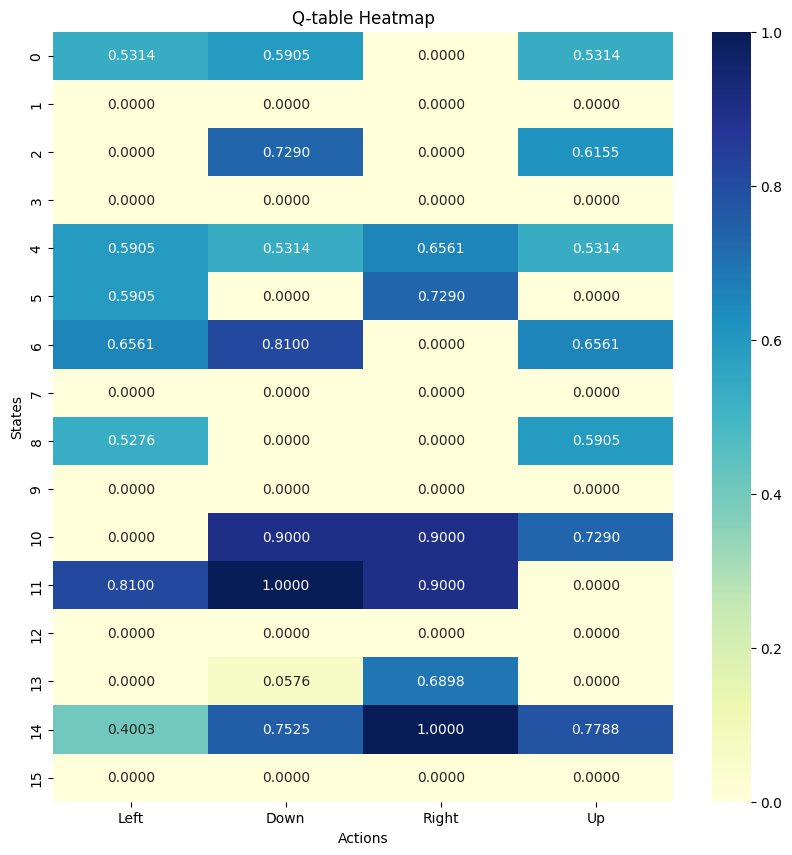

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [29]:
plt.figure(figsize=(10, 10))
sns.heatmap(q_table, annot=True, fmt=".4f", cmap="YlGnBu",
cbar=True)

plt.xlabel('Actions')
plt.ylabel('States')
plt.title('Q-table Heatmap')
plt.xticks(ticks=np.arange(4) + 0.5, labels=["Left", "Down","Right", "Up"])
plt.show()

In [30]:
def play_frozen_lake(q_table, env, episodes=5, max_steps_per_episode=100):

    all_episodes_routes = []
    all_episodes_results = []

    for episode in range(episodes):

        state, _ = env.reset()

        done = False
        route = []

        time.sleep(1)

        for step in range(max_steps_per_episode):

            clear_output(wait=True)

            print(f"EPISODE {episode+1} - STEP {step+1}")

            rendered_output = "".join(env.render())
            sys.stdout.write(rendered_output + "\n")
            sys.stdout.flush()

            time.sleep(0.3)

            action = np.argmax(q_table[state, :])

            new_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            route.append(state)

            if done:

                state = new_state
                route.append(state)

                clear_output(wait=True)

                print(f"EPISODE {episode+1} - STEP {step+1}")

                rendered_output = "".join(env.render())
                sys.stdout.write(rendered_output + "\n")
                sys.stdout.flush()

                if reward == 1:
                    print("You reached the goal!")
                    all_episodes_results.append("Berhasil")

                else:
                    print("You fell through a hole!")
                    all_episodes_results.append("Gagal")

                time.sleep(3)

                break

            state = new_state

        all_episodes_routes.append(route)

    env.close()

    print("\nHasil Semua Episode")

    for episode_num, (route, result) in enumerate(
        zip(all_episodes_routes, all_episodes_results), 1
    ):

        print(f"Episode {episode_num}: {result}")
        print(f"Rute yang ditempuh: {route}\n")


play_frozen_lake(q_table, env)

EPISODE 5 - STEP 6
  (Down)
SHFH
FFFH
FHFF
HFFG

You reached the goal!

Hasil Semua Episode
Episode 1: Berhasil
Rute yang ditempuh: [0, 4, 5, 6, 10, 11, 15]

Episode 2: Berhasil
Rute yang ditempuh: [0, 4, 5, 6, 10, 11, 15]

Episode 3: Berhasil
Rute yang ditempuh: [0, 4, 5, 6, 10, 11, 15]

Episode 4: Berhasil
Rute yang ditempuh: [0, 4, 5, 6, 10, 11, 15]

Episode 5: Berhasil
Rute yang ditempuh: [0, 4, 5, 6, 10, 11, 15]

